In [ ]:
import torch
import os
from torch import nn
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




class Tetris_shapes(nn.Module):
    def __init__(self,input_features, output_features, hidden_units):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(nn.Linear(in_features=input_features, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=output_features))

        for layer in self.linear_layer_stack:
          if isinstance(layer, nn.Linear):
            nn.init.kaiming_uniform_(layer.weight)



    def forward(self, x):
        return self.linear_layer_stack(x)


model_linear_correlated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_linear_uncorrelated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_multiplicative_correlated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_multiplicative_uncorrelated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_translation_rotations_correlated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_translation_rotations_uncorrelated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_xor_correlated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)
model_xor_uncorrelated_data =  Tetris_shapes(input_features=64, output_features=2, hidden_units=10)


In [ ]:
for layer in model_linear_correlated_data.linear_layer_stack:
  print(f"{layer}")

Linear(in_features=64, out_features=10, bias=True)
ReLU()
Linear(in_features=10, out_features=10, bias=True)
ReLU()
Linear(in_features=10, out_features=2, bias=True)


In [ ]:
model_linear_correlated_data_dict = torch.load("/content/linear_1d1p_0.0125_correlated.pt")
model_linear_uncorrelated_data_dict = torch.load("/content/linear_1d1p_0.18_uncorrelated.pt")
model_multiplicative_correlated_data_dict = torch.load("/content/multiplicative_1d1p_0.1_correlated.pt")
model_multiplicative_uncorrelated_data_dict = torch.load("/content/multiplicative_1d1p_0.7_uncorrelated.pt")
model_translation_rotations_correlated_data_dict = torch.load("/content/translations_rotations_1d1p_0.2_correlated.pt")
model_translation_rotations_uncorrelated_data_dict = torch.load("/content/translations_rotations_1d1p_0.65_uncorrelated.pt")
model_xor_correlated_data_dict = torch.load("/content/xor_1d1p_0.15_correlated.pt")
model_xor_uncorrelated_data_dict = torch.load("/content/xor_1d1p_0.35_uncorrelated.pt")

<ipython-input-26-6f28e884d689>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_linear_correlated_data_dict = torch.load("/content/linear_1d1p_0.0125_correlated.pt")


In [ ]:
model_linear_correlated_data_dict["x_train"],model_linear_correlated_data_dict["x_test"],model_linear_correlated_data_dict["y_train"].dtype,model_linear_correlated_data_dict["y_test"]

(tensor([[ 0.4595,  0.4404,  0.4080,  ..., -0.1689, -0.2634, -0.3142],
         [-0.3101, -0.2974, -0.2776,  ..., -0.3525, -0.3887, -0.4099],
         [ 0.2563,  0.2505,  0.2391,  ..., -0.0273, -0.0062,  0.0040],
         ...,
         [-0.3755, -0.3416, -0.2754,  ..., -0.1013, -0.0690, -0.0504],
         [ 0.2815,  0.2866,  0.2942,  ...,  0.3232,  0.3667,  0.3887],
         [ 0.3982,  0.3591,  0.2825,  ..., -0.0452, -0.1370, -0.1873]],
        dtype=torch.float16),
 tensor([[ 0.0401,  0.0514,  0.0709,  ..., -0.2096, -0.2739, -0.3091],
         [ 0.2389,  0.2228,  0.2019,  ...,  0.0570,  0.1263,  0.1653],
         [-0.1154, -0.1078, -0.0895,  ..., -0.0295,  0.0330,  0.0714],
         ...,
         [ 0.1088,  0.1139,  0.1261,  ...,  0.4983,  0.5337,  0.5547],
         [ 0.1757,  0.1689,  0.1509,  ...,  0.0446,  0.0247,  0.0119],
         [ 0.1846,  0.1692,  0.1425,  ...,  0.3386,  0.3872,  0.4133]],
        dtype=torch.float16),
 torch.int64,
 tensor([1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,

In [ ]:
model_linear_correlated_data_dict["y_train"]
x_train = torch.tensor(np.array(model_linear_correlated_data_dict["x_train"], dtype=np.float32))
y_train = torch.tensor(np.array(model_linear_correlated_data_dict["y_train"], dtype=np.float32))
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
for batch_idx, (batch_data, batch_labels) in enumerate(train_loader):
    if batch_idx == 0:  # Extract the first batch
        single_batch_data = batch_data
        single_batch_labels = batch_labels
        break  # Exit the loop after extracting the first batch

# Print the extracted batch
print("Single Batch Data:", single_batch_data.shape)
print("Single Batch Labels:", single_batch_labels.shape)

Single Batch Data: torch.Size([32, 64])
Single Batch Labels: torch.Size([32])


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import numpy as np

def training_model_dicts(model: torch.nn.Module, model_dict: dict, epochs : int = 10):

    x_train = torch.tensor(np.array(model_dict["x_train"], dtype=np.float32))
    y_train = torch.tensor(np.array(model_dict["y_train"], dtype=np.int64))
    x_test = torch.tensor(np.array(model_dict["x_val"], dtype=np.float32))
    y_test = torch.tensor(np.array(model_dict["y_val"], dtype=np.int64))


    train_dataset = TensorDataset(x_train, y_train)
    test_dataset = TensorDataset(x_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []
             }


    for epochs in tqdm(range(epochs)):
        model.train()
        train_loss = 0
        train_acc = 0
        for batch ,(x_batch, y_batch) in enumerate(train_loader):
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            train_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
            train_acc += (y_pred_class == y_batch).sum().item() / len(y_pred)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        model.eval()
        test_loss = 0
        test_acc = 0
        with torch.inference_mode():
            total_loss = 0
            for batch ,(x_batch, y_batch) in enumerate(test_loader):
                test_y_pred = model(x_batch)
                loss = loss_fn(test_y_pred, y_batch)
                test_loss += loss.item()
                y_pred_class = torch.argmax(torch.softmax(test_y_pred, dim=1), dim=1)
                test_acc += (y_pred_class == y_batch).sum().item() / len(test_y_pred)

            test_loss /= len(test_loader)
            test_acc /= len(test_loader)


        print(
        f"Epoch: {epochs+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
        )


        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results




In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_linear_correlated_data_results = training_model_dicts(model=model_linear_correlated_data, model_dict=model_linear_correlated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6946 | train_acc: 0.5026 | test_loss: 0.6905 | test_acc: 0.5225
Epoch: 2 | train_loss: 0.6928 | train_acc: 0.5091 | test_loss: 0.6911 | test_acc: 0.5322
Epoch: 3 | train_loss: 0.6922 | train_acc: 0.5198 | test_loss: 0.6904 | test_acc: 0.5264
Epoch: 4 | train_loss: 0.6917 | train_acc: 0.5244 | test_loss: 0.6908 | test_acc: 0.5156
Epoch: 5 | train_loss: 0.6908 | train_acc: 0.5266 | test_loss: 0.6903 | test_acc: 0.5332
Epoch: 6 | train_loss: 0.6891 | train_acc: 0.5419 | test_loss: 0.6891 | test_acc: 0.5361
Epoch: 7 | train_loss: 0.6867 | train_acc: 0.5569 | test_loss: 0.6859 | test_acc: 0.5732
Epoch: 8 | train_loss: 0.6794 | train_acc: 0.5876 | test_loss: 0.6750 | test_acc: 0.5635
Epoch: 9 | train_loss: 0.6595 | train_acc: 0.6554 | test_loss: 0.6418 | test_acc: 0.7266
Epoch: 10 | train_loss: 0.6167 | train_acc: 0.7490 | test_loss: 0.5891 | test_acc: 0.8047
Epoch: 11 | train_loss: 0.5548 | train_acc: 0.8456 | test_loss: 0.5058 | test_acc: 0.9141
Epoch: 12 | train_l

In [ ]:
import torch
import os
import pickle


MODEL_PATH = "linear_correlated_model.pth"
torch.save(model_linear_correlated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "linear_correlated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_linear_correlated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to linear_correlated_model.pth
Results saved to linear_correlated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_linear_uncorrelated_data_results = training_model_dicts(model=model_linear_uncorrelated_data, model_dict=model_linear_uncorrelated_data_dict, epochs=50)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2131 | train_acc: 0.9115 | test_loss: 0.2755 | test_acc: 0.8896
Epoch: 2 | train_loss: 0.2120 | train_acc: 0.9125 | test_loss: 0.2787 | test_acc: 0.8945
Epoch: 3 | train_loss: 0.2114 | train_acc: 0.9107 | test_loss: 0.2790 | test_acc: 0.8916
Epoch: 4 | train_loss: 0.2108 | train_acc: 0.9136 | test_loss: 0.2807 | test_acc: 0.8896
Epoch: 5 | train_loss: 0.2104 | train_acc: 0.9121 | test_loss: 0.2825 | test_acc: 0.8887
Epoch: 6 | train_loss: 0.2096 | train_acc: 0.9131 | test_loss: 0.2860 | test_acc: 0.8877
Epoch: 7 | train_loss: 0.2094 | train_acc: 0.9117 | test_loss: 0.2853 | test_acc: 0.8916
Epoch: 8 | train_loss: 0.2083 | train_acc: 0.9129 | test_loss: 0.2882 | test_acc: 0.8896
Epoch: 9 | train_loss: 0.2079 | train_acc: 0.9133 | test_loss: 0.2893 | test_acc: 0.8906
Epoch: 10 | train_loss: 0.2079 | train_acc: 0.9153 | test_loss: 0.2892 | test_acc: 0.8916
Epoch: 11 | train_loss: 0.2065 | train_acc: 0.9136 | test_loss: 0.2916 | test_acc: 0.8867
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "linear_uncorrelated_model.pth"
torch.save(model_linear_uncorrelated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "linear_unorrelated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_linear_uncorrelated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to linear_uncorrelated_model.pth
Results saved to linear_unorrelated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_multiplicative_correlated_data_results = training_model_dicts(model=model_multiplicative_correlated_data, model_dict=model_multiplicative_correlated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6953 | train_acc: 0.5144 | test_loss: 0.6905 | test_acc: 0.5303
Epoch: 2 | train_loss: 0.6900 | train_acc: 0.5272 | test_loss: 0.6869 | test_acc: 0.5439
Epoch: 3 | train_loss: 0.6878 | train_acc: 0.5459 | test_loss: 0.6853 | test_acc: 0.5654
Epoch: 4 | train_loss: 0.6851 | train_acc: 0.5724 | test_loss: 0.6842 | test_acc: 0.5352
Epoch: 5 | train_loss: 0.6815 | train_acc: 0.5704 | test_loss: 0.6782 | test_acc: 0.6182
Epoch: 6 | train_loss: 0.6749 | train_acc: 0.5956 | test_loss: 0.6763 | test_acc: 0.5352
Epoch: 7 | train_loss: 0.6668 | train_acc: 0.6045 | test_loss: 0.6619 | test_acc: 0.5986
Epoch: 8 | train_loss: 0.6479 | train_acc: 0.6518 | test_loss: 0.6352 | test_acc: 0.6865
Epoch: 9 | train_loss: 0.6248 | train_acc: 0.6963 | test_loss: 0.6132 | test_acc: 0.7227
Epoch: 10 | train_loss: 0.5855 | train_acc: 0.7465 | test_loss: 0.5704 | test_acc: 0.7373
Epoch: 11 | train_loss: 0.5397 | train_acc: 0.7999 | test_loss: 0.5251 | test_acc: 0.8203
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "multiplicative_correlated_model.pth"
torch.save(model_multiplicative_correlated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "multiplicative_correlated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_multiplicative_correlated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to multiplicative_correlated_model.pth
Results saved to multiplicative_correlated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_multiplicative_uncorrelated_data_results = training_model_dicts(model=model_multiplicative_uncorrelated_data, model_dict=model_multiplicative_uncorrelated_data_dict, epochs=50)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0932 | train_acc: 0.9616 | test_loss: 0.1884 | test_acc: 0.9277
Epoch: 2 | train_loss: 0.0914 | train_acc: 0.9635 | test_loss: 0.1918 | test_acc: 0.9287
Epoch: 3 | train_loss: 0.0909 | train_acc: 0.9647 | test_loss: 0.1931 | test_acc: 0.9287
Epoch: 4 | train_loss: 0.0902 | train_acc: 0.9650 | test_loss: 0.1948 | test_acc: 0.9199
Epoch: 5 | train_loss: 0.0887 | train_acc: 0.9639 | test_loss: 0.1919 | test_acc: 0.9326
Epoch: 6 | train_loss: 0.0878 | train_acc: 0.9651 | test_loss: 0.1908 | test_acc: 0.9287
Epoch: 7 | train_loss: 0.0889 | train_acc: 0.9649 | test_loss: 0.1904 | test_acc: 0.9326
Epoch: 8 | train_loss: 0.0877 | train_acc: 0.9656 | test_loss: 0.1906 | test_acc: 0.9258
Epoch: 9 | train_loss: 0.0870 | train_acc: 0.9671 | test_loss: 0.1945 | test_acc: 0.9268
Epoch: 10 | train_loss: 0.0865 | train_acc: 0.9653 | test_loss: 0.1955 | test_acc: 0.9248
Epoch: 11 | train_loss: 0.0860 | train_acc: 0.9667 | test_loss: 0.1974 | test_acc: 0.9229
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "multiplicative_uncorrelated_model.pth"
torch.save(model_multiplicative_uncorrelated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "multiplicative_uncorrelated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_multiplicative_uncorrelated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to multiplicative_uncorrelated_model.pth
Results saved to multiplicative_uncorrelated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_translation_rotations_correlated_data_results = training_model_dicts(model=model_translation_rotations_correlated_data, model_dict=model_translation_rotations_correlated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6967 | train_acc: 0.5005 | test_loss: 0.6942 | test_acc: 0.4902
Epoch: 2 | train_loss: 0.6934 | train_acc: 0.5089 | test_loss: 0.6946 | test_acc: 0.4922
Epoch: 3 | train_loss: 0.6926 | train_acc: 0.5156 | test_loss: 0.6947 | test_acc: 0.5010
Epoch: 4 | train_loss: 0.6925 | train_acc: 0.5114 | test_loss: 0.6939 | test_acc: 0.5059
Epoch: 5 | train_loss: 0.6920 | train_acc: 0.5164 | test_loss: 0.6938 | test_acc: 0.5020
Epoch: 6 | train_loss: 0.6914 | train_acc: 0.5206 | test_loss: 0.6941 | test_acc: 0.5107
Epoch: 7 | train_loss: 0.6914 | train_acc: 0.5225 | test_loss: 0.6941 | test_acc: 0.5107
Epoch: 8 | train_loss: 0.6911 | train_acc: 0.5221 | test_loss: 0.6945 | test_acc: 0.5000
Epoch: 9 | train_loss: 0.6907 | train_acc: 0.5288 | test_loss: 0.6942 | test_acc: 0.5049
Epoch: 10 | train_loss: 0.6900 | train_acc: 0.5304 | test_loss: 0.6944 | test_acc: 0.5049
Epoch: 11 | train_loss: 0.6899 | train_acc: 0.5278 | test_loss: 0.6957 | test_acc: 0.4941
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "translation_rotations_correlated_model.pth"
torch.save(model_translation_rotations_correlated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "translation_rotations_correlated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_translation_rotations_correlated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to translation_rotations_correlated_model.pth
Results saved to translation_rotations_correlated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_translation_rotations_uncorrelated_data_results = training_model_dicts(model=model_translation_rotations_uncorrelated_data, model_dict=model_translation_rotations_uncorrelated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7001 | train_acc: 0.5131 | test_loss: 0.6932 | test_acc: 0.5156
Epoch: 2 | train_loss: 0.6857 | train_acc: 0.5530 | test_loss: 0.6867 | test_acc: 0.5518
Epoch: 3 | train_loss: 0.6749 | train_acc: 0.5861 | test_loss: 0.6767 | test_acc: 0.5742
Epoch: 4 | train_loss: 0.6574 | train_acc: 0.6244 | test_loss: 0.6574 | test_acc: 0.6201
Epoch: 5 | train_loss: 0.6287 | train_acc: 0.6656 | test_loss: 0.6197 | test_acc: 0.6836
Epoch: 6 | train_loss: 0.5788 | train_acc: 0.7196 | test_loss: 0.5578 | test_acc: 0.7451
Epoch: 7 | train_loss: 0.5160 | train_acc: 0.7675 | test_loss: 0.4936 | test_acc: 0.7852
Epoch: 8 | train_loss: 0.4569 | train_acc: 0.8023 | test_loss: 0.4386 | test_acc: 0.8086
Epoch: 9 | train_loss: 0.4082 | train_acc: 0.8301 | test_loss: 0.3952 | test_acc: 0.8320
Epoch: 10 | train_loss: 0.3710 | train_acc: 0.8466 | test_loss: 0.3645 | test_acc: 0.8447
Epoch: 11 | train_loss: 0.3445 | train_acc: 0.8596 | test_loss: 0.3393 | test_acc: 0.8604
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "translation_rotations_uncorrelated_model.pth"
torch.save(model_translation_rotations_uncorrelated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "translation_rotations_uncorrelated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_translation_rotations_uncorrelated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to translation_rotations_uncorrelated_model.pth
Results saved to translation_rotations_uncorrelated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_xor_correlated_data_results = training_model_dicts(model= model_xor_correlated_data, model_dict= model_xor_correlated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6548 | train_acc: 0.7130 | test_loss: 0.5362 | test_acc: 0.9893
Epoch: 2 | train_loss: 0.3200 | train_acc: 0.9991 | test_loss: 0.1839 | test_acc: 1.0000
Epoch: 3 | train_loss: 0.1233 | train_acc: 1.0000 | test_loss: 0.0818 | test_acc: 1.0000
Epoch: 4 | train_loss: 0.0416 | train_acc: 1.0000 | test_loss: 0.0195 | test_acc: 1.0000
Epoch: 5 | train_loss: 0.0115 | train_acc: 1.0000 | test_loss: 0.0072 | test_acc: 1.0000
Epoch: 6 | train_loss: 0.0051 | train_acc: 1.0000 | test_loss: 0.0037 | test_acc: 1.0000
Epoch: 7 | train_loss: 0.0028 | train_acc: 1.0000 | test_loss: 0.0023 | test_acc: 1.0000
Epoch: 8 | train_loss: 0.0018 | train_acc: 1.0000 | test_loss: 0.0015 | test_acc: 1.0000
Epoch: 9 | train_loss: 0.0012 | train_acc: 1.0000 | test_loss: 0.0011 | test_acc: 1.0000
Epoch: 10 | train_loss: 0.0009 | train_acc: 1.0000 | test_loss: 0.0008 | test_acc: 1.0000
Epoch: 11 | train_loss: 0.0007 | train_acc: 1.0000 | test_loss: 0.0006 | test_acc: 1.0000
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "xor_correlated_model.pth"
torch.save(model_xor_correlated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "xor_correlated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_xor_correlated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to xor_correlated_model.pth
Results saved to xor_correlated_results.pkl


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()
model_xor_uncorrelated_data_results = training_model_dicts(model= model_xor_uncorrelated_data, model_dict= model_xor_uncorrelated_data_dict, epochs=100)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5756 | train_acc: 0.7063 | test_loss: 0.3017 | test_acc: 0.9512
Epoch: 2 | train_loss: 0.1308 | train_acc: 0.9868 | test_loss: 0.0441 | test_acc: 0.9951
Epoch: 3 | train_loss: 0.0305 | train_acc: 0.9960 | test_loss: 0.0185 | test_acc: 0.9961
Epoch: 4 | train_loss: 0.0167 | train_acc: 0.9970 | test_loss: 0.0114 | test_acc: 0.9971
Epoch: 5 | train_loss: 0.0115 | train_acc: 0.9976 | test_loss: 0.0085 | test_acc: 0.9980
Epoch: 6 | train_loss: 0.0090 | train_acc: 0.9981 | test_loss: 0.0076 | test_acc: 0.9971
Epoch: 7 | train_loss: 0.0073 | train_acc: 0.9984 | test_loss: 0.0065 | test_acc: 0.9980
Epoch: 8 | train_loss: 0.0060 | train_acc: 0.9986 | test_loss: 0.0056 | test_acc: 0.9990
Epoch: 9 | train_loss: 0.0050 | train_acc: 0.9991 | test_loss: 0.0053 | test_acc: 0.9971
Epoch: 10 | train_loss: 0.0043 | train_acc: 0.9995 | test_loss: 0.0047 | test_acc: 0.9971
Epoch: 11 | train_loss: 0.0037 | train_acc: 0.9995 | test_loss: 0.0042 | test_acc: 0.9990
Epoch: 12 | train_l

In [ ]:
MODEL_PATH = "xor_uncorrelated_model.pth"
torch.save(model_xor_uncorrelated_data.state_dict(), MODEL_PATH)

RESULTS_PATH = "xor_uncorrelated_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(model_xor_uncorrelated_data_results, f)

print(f"Model saved to {MODEL_PATH}")
print(f"Results saved to {RESULTS_PATH}")

Model saved to xor_uncorrelated_model.pth
Results saved to xor_uncorrelated_results.pkl


In [ ]:
def collect_activation(model,x):
  x= torch.tensor(np.array(x, dtype=np.float32))
  with torch.no_grad():
    layers = [model.linear_layer_stack[i] for i in range(len(model.linear_layer_stack))]
    activation = []
    for layer in layers:
      x = layer(x)
      activation.append(x)
  return activation


In [ ]:
model_linear_correlated_data_dict["x_train"]

tensor([[ 0.4595,  0.4404,  0.4080,  ..., -0.1689, -0.2634, -0.3142],
        [-0.3101, -0.2974, -0.2776,  ..., -0.3525, -0.3887, -0.4099],
        [ 0.2563,  0.2505,  0.2391,  ..., -0.0273, -0.0062,  0.0040],
        ...,
        [-0.3755, -0.3416, -0.2754,  ..., -0.1013, -0.0690, -0.0504],
        [ 0.2815,  0.2866,  0.2942,  ...,  0.3232,  0.3667,  0.3887],
        [ 0.3982,  0.3591,  0.2825,  ..., -0.0452, -0.1370, -0.1873]],
       dtype=torch.float16)

In [ ]:
acts = collect_activation(model_linear_correlated_data,model_linear_correlated_data_dict["x_train"])
acts

[tensor([[-0.2653,  0.1229,  0.1465,  ...,  0.1234,  0.0429,  0.0229],
         [-0.1570,  0.1670,  0.1146,  ...,  0.0723,  0.1562,  0.1308],
         [-0.1426,  0.1960,  0.2397,  ...,  0.0887,  0.0692,  0.1089],
         ...,
         [-0.1815,  0.1348,  0.1131,  ...,  0.1611,  0.1140,  0.1551],
         [-0.1357,  0.1590,  0.2545,  ...,  0.1007,  0.0289,  0.1228],
         [-0.1773,  0.1568,  0.2032,  ...,  0.0664,  0.0751,  0.0465]]),
 tensor([[0.0000, 0.1229, 0.1465,  ..., 0.1234, 0.0429, 0.0229],
         [0.0000, 0.1670, 0.1146,  ..., 0.0723, 0.1562, 0.1308],
         [0.0000, 0.1960, 0.2397,  ..., 0.0887, 0.0692, 0.1089],
         ...,
         [0.0000, 0.1348, 0.1131,  ..., 0.1611, 0.1140, 0.1551],
         [0.0000, 0.1590, 0.2545,  ..., 0.1007, 0.0289, 0.1228],
         [0.0000, 0.1568, 0.2032,  ..., 0.0664, 0.0751, 0.0465]]),
 tensor([[ 0.3745,  0.1478,  0.3767,  ..., -0.4570, -0.4025,  0.9443],
         [ 0.8666,  0.6268,  1.1563,  ..., -0.5600, -0.4092,  0.1243],
         [

<ipython-input-75-cbf6f0f45733>:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t= torch.tensor(t)


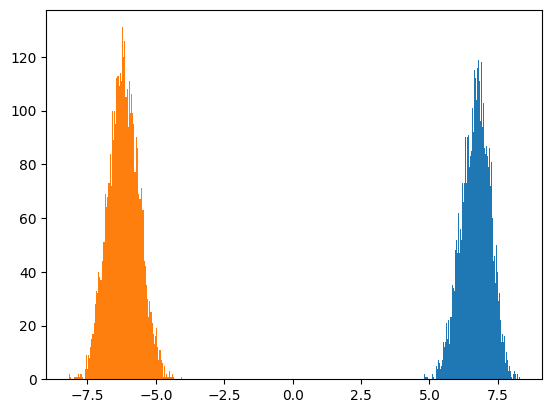

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
a= acts[-1]
b= a[:,0]
t = model_linear_correlated_data_dict["y_train"]
t= torch.tensor(t)
act1 = b[t==0]
act2 = b[t==1]

plt.hist(act1,bins=100,label="positive")
plt.hist(act2,bins=100,label="negative")


plt.show()




In [ ]:
act1.shape,act2.shape

(torch.Size([4000]), torch.Size([4000]))

In [ ]:
print